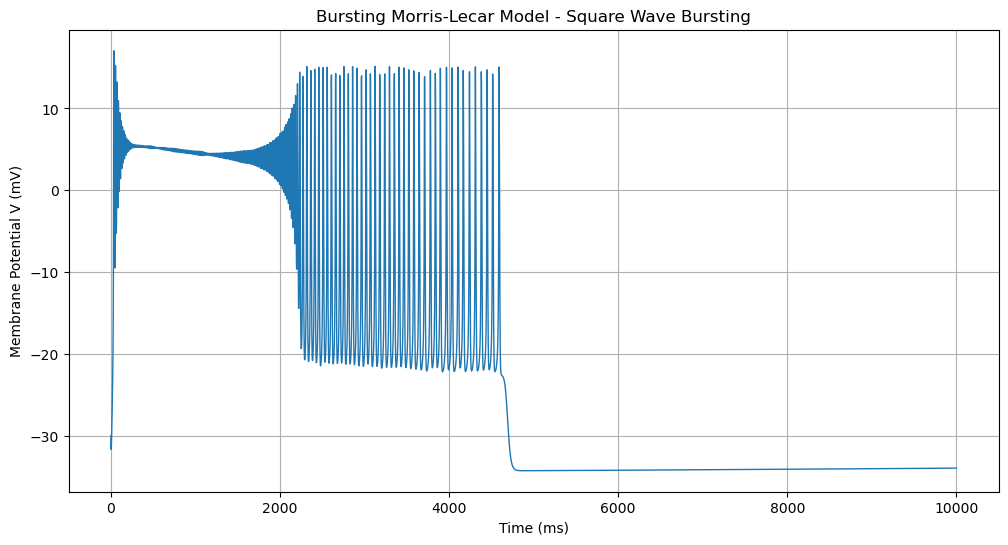

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# --- Model Parameters ---
# Select the regime: 'square' or 'elliptic'
REGIME = 'square'  # Pick 'square' or 'elliptic' for the other regime

# Common known parameters
C_m = 20.0
V_Ca = 120.0
V_K = -84.0
V_L = -60.0
K_d = 3.0          # Calcium dissociation constant (often used)
k_pmca = 0.1       # Calcium pump rate

if REGIME == 'square':
    phi, g_Ca, V_3, V_4, g_K, g_L, V_1, V_2, g_KCa, I_app = 0.23, 4.0, 12.0, 17.4, 8.0, 2.0, -1.2, 18.0, 0.25, 50.
    # phi, g_Ca, V_3, V_4, g_K, g_L, V_1, V_2, g_KCa, I_app = 0.23, 4.0, 12.0, 17.4, 8.0, 2.0, -1.2, 18.0, 0.25, 45
    eps, mu = 0.0005, 0.02
    # eps, mu = 0.005, 0.02
else:  # elliptic
    phi, g_Ca, V_3, V_4, g_K, g_L, V_1, V_2, g_KCa, I_app = 0.04, 4.4, 2.0, 30.0, 8.0, 2.0, -1.2, 18.0, 0.75, 140
    # phi, g_Ca, V_3, V_4, g_K, g_L, V_1, V_2, g_KCa, I_app = 0.04, 4.4, 2.0, 30.0, 8.0, 2.0, -1.2, 18.0, 0.75, 120
    eps, mu = 0.005, 0.02

# --- Auxiliary Functions ---
def m_inf(V):
    return 0.5 * (1 + np.tanh((V - V_1) / V_2))

def n_inf(V):
    return 0.5 * (1 + np.tanh((V - V_3) / V_4))

def tau_n(V):
    return 1 / np.cosh((V - V_3) / (2 * V_4))

def I_Ca(V):
    return g_Ca * m_inf(V) * (V - V_Ca)

# --- Morris-Lecar ODEs (3-variable bursting version) ---
def ml_burst(t, y):
    V, n, Ca = y
    I_KCa = g_KCa * (Ca**3 / (Ca**3 + K_d**3)) * (V - V_K)
    dV = (I_app - g_L*(V - V_L) - I_Ca(V) - g_K * n * (V - V_K) - I_KCa) / C_m
    dn = phi * (n_inf(V) - n) / tau_n(V)
    dCa = eps * (-mu * I_Ca(V) - k_pmca * Ca)
    return [dV, dn, dCa]

# --- Simulation Setup ---
V0 = -30.0  # Initial voltage
n0 = 0.1    # Initial K+ activation
Ca0 = 0.2   # Initial Calcium concentration
t_end = 10000
t_span = (0, t_end)  # Simulate for 1000 ms
t_eval = np.linspace(t_span[0], t_span[1], 5000)

# --- Run Simulation ---
sol = solve_ivp(ml_burst, t_span, [V0, n0, Ca0], t_eval=t_eval, method='LSODA')

# --- Plot Results ---
plt.figure(figsize=(12, 6))
plt.plot(sol.t, sol.y[0], linewidth=1)
plt.xlabel('Time (ms)')
plt.ylabel('Membrane Potential V (mV)')
plt.title(f'Bursting Morris-Lecar Model - {REGIME.capitalize()} Wave Bursting')
plt.grid(True)
plt.show()